# Machine Learning Exercise 1: Regression Basics

In this exercise, you'll be working with a dataset on house sales in King County, Washington. You can get more information about this dataset [here](https://www.kaggle.com/datasets/harlfoxem/housesalesprediction). Our first goal is to build a predictive model for the sales price.

We'll start with a simple model, one which uses just the square footage of living space as our only predictor variable.

In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import (r2_score,
                            mean_squared_error,
                            root_mean_squared_error,
                            mean_absolute_error,
                            mean_absolute_percentage_error)

## 1. Before building the model, start by looking at a scatterplot of price vs. the square footage of living space. What do you find? How strong does the relationship appear to be?

### ANSWER: Moderate positive correlation

In [11]:
kc_house_df = pd.read_csv('data/kc_house_data.csv')
kc_house_df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


<Axes: xlabel='sqft_living', ylabel='price'>

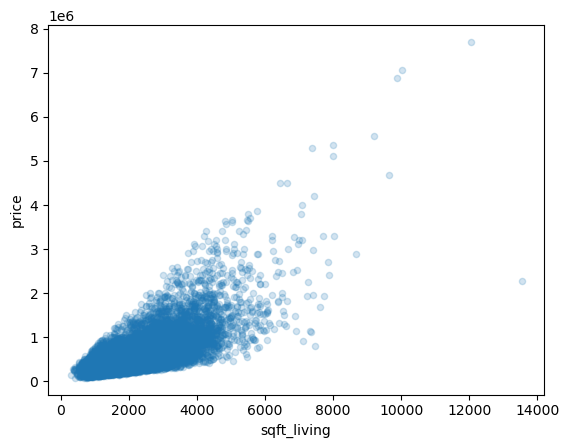

In [12]:
kc_house_df.plot(
    x='sqft_living',
    y='price',
    kind='scatter',
    alpha=0.2
)

Now, let's work towards building the model. 

## 2. Create a DataFrame, X, which contains one column, the sqft_living space and a Series, y, which contains the target variable.

In [25]:
X = kc_house_df[['sqft_living']]
X.head()

,sqft_living
0,1180
1,2570
2,770
3,1960
4,1680


In [16]:
y = kc_house_df['price']
y.head()

0    221900.0
1    538000.0
2    180000.0
3    604000.0
4    510000.0
Name: price, dtype: float64

One of the most important concepts when it comes to machine learning is that the only performance we care about is how well the model predicts on data that it has not seen yet.

One way to accomplish this is through setting aside a portion of the data as a **test set** and to train the model on the remaining portion.

## 3. Use the [train_test_split function](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) to create a training and a test set from X and y. Name the resulting pieces X_train, X_test, y_train, and y_test. When you do this, use 30% of the data in the test set. Also, use the random_state parameter so that we can compare model performance as we change the way we build our model.

In [33]:
random_state = 42

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=random_state
)

Now, we need to fit our model. We'll start with a linear regression model. 

## 4. Import the [LinearRegression class](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) from the linear_model module. Then create a linear regression instance and fit it to the training data.

In [37]:
model = LinearRegression().fit(X_train, y_train)

In some cases, we may want to inspect the model after it has been fit. Here, since we are working with a linear regression model, we could inspect the coefficients. 

## 5. What is the intercept term, and what is the coefficient for sqft_living? How can you interpret how the model is using sqft_living to make predictions? Hint: You can get these values by looking at the .intercept_ and .coef_ attributes of the fit model.

### ANSWER: The intercept/bias is -41,947.454 bc you can't have 0 sqft_living. For every sqft_living increment, the price increases by $279.51.

In [40]:
model.intercept_

np.float64(-41947.45401876245)

In [39]:
model.coef_

array([279.51011741])

In [41]:
-41947.454/279.51

-150.07496690637186

The next step is to evaluate how well the model does on the unseen data. 

## 6. Use the predict method to generate a set of predictions on X_test. Save the results to y_pred. Question: What type of object is y_pred? What is its shape and how does it compare to y_test?

### ANSWER: y_pred is an array with the same length (6,484) as y_test.

In [42]:
y_pred = model.predict(X_test)

In [45]:
y_pred

array([ 536638.48902466,  768631.88647686, 1011805.68862555, ...,
        279489.18100536,  556204.19724352,  659622.94068607],
      shape=(6484,))

In [46]:
y_test

735       365000.0
2830      865000.0
4106     1038000.0
16218    1490000.0
19964     711000.0
           ...    
12606     412000.0
14393     760000.0
6899      410500.0
85        940000.0
21363     410000.0
Name: price, Length: 6484, dtype: float64

Now, we can evaluate how well the model did. There are a number of different metrics that could be used. Let's look at five of them, mean squared error, root mean squared error, mean absolute error, mean absolute percentage error, and R^2 score. For more information on these metrics, see https://developer.nvidia.com/blog/a-comprehensive-overview-of-regression-evaluation-metrics/.

## 7. Calculate each metric on the test set. For each one, interpret what the number means.

In [51]:
# R² Score - The coefficient of determinateion
# Compares the residual sum of squares (RSS) to the total sum of squares (TSS).
# Corresponds to the degree to which the variance in the dependent variable (the target) 
# can be explained by the independent variables (features). 
# A rough estimate of how the model performs.
print(model.score(X_test, y_test))
# or
print(r2_score(y_test, y_pred))

0.48388319278201475
0.48388319278201475


In [52]:
# MSE - Mean squared error regression loss
# A non-negative floating point value (the best value is 0.0).
# Puts a significantly heavier penalty on large errors.
# Not measured in the original units.
mean_squared_error(y_test, y_pred)

74509993356.49603

In [53]:
# RMSE - Root mean squared error regression loss
# A non-negative floating point value (the best value is 0.0).
# Although RMSE is on the same scale as the target, 
# an RMSE of 10 does not actually mean you are off by 10 units on average.
root_mean_squared_error(y_test, y_pred)

272965.1870779423

In [50]:
# MAE - Mean absolute error regression loss: a risk metric corresponding to the expected value of the absolute error loss.
# The weighted average of all output errors,
# a non-negative floating point value, where best value is 0.0.
# The metric is expressed at the same scale as the target variable, making it easier to interpret. 
mean_absolute_error(y_test, y_pred)

177803.0458452365

In [54]:
# MAPE - Mean absolute percentage error (MAPE) regression loss
# Sensitive to relative errors.
# The weighted average of all output errors,
# a non-negative floating point value, where best value is 0.0.
# Doesn’t work if any of the targets are 0.
mean_absolute_percentage_error(y_test, y_pred)

0.36040933275597725

It's always a good idea to see how well your model performs against a simple baseline. In the case of regression, a very simple model would be one that just predicts the overall average home price on the training data.

## 8. Create a numpy array that is the same length as y_test which just contains a constant value equal to the mean of the target variable on the training data. Hint: you could use the [full_like function from numpy](https://numpy.org/doc/2.2/reference/generated/numpy.full_like.html) to create this array. Does the model using sqft_living do better than this simple baseline model?

### ANSWER: Seems like the model performs slightly better than the baseline.

In [56]:
baseline_test = np.full_like(
    a=y_test,
    fill_value=y_test.mean()
)

In [61]:
# R² Score
print(r2_score(y_test, y_pred))
print(r2_score(baseline_test, y_pred))

0.48388319278201475
0.0


In [62]:
# MSE
print(mean_squared_error(y_test, y_pred))
print(mean_squared_error(baseline_test, y_pred))

74509993356.49603
68135575944.89954


In [63]:
# RMSE
print(root_mean_squared_error(y_test, y_pred))
print(root_mean_squared_error(baseline_test, y_pred))

272965.1870779423
261027.92177255586


In [64]:
# MAE
print(mean_absolute_error(y_test, y_pred))
print(mean_absolute_error(baseline_test, y_pred))

177803.0458452365
196902.5782881442


In [65]:
# MAPE
print(mean_absolute_percentage_error(y_test, y_pred))
print(mean_absolute_percentage_error(baseline_test, y_pred))

0.36040933275597725
0.3607596170495462


While we started with a linear regression model, there are other types of models that we could try out. A k-nearest-neighbors model generates predictions by finding the most similar points in the training data and averaging their target values. It is a non-parametric model and doesn't assume a particular form for the relationship between the features and the target. 

## 9. Fit a [KNeighborsRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html) to the data using just the square footage of living space and using 5 neighbors. How do the metrics compare to those for the linear regression model?

### ANSWER: k-nearest-neighbors model seems worse.

In [66]:
k_model = KNeighborsRegressor().fit(X_train, y_train)

In [68]:
ky_pred = k_model.predict(X_test)

In [69]:
# R² Score
print(r2_score(y_test, y_pred))
print(r2_score(y_test, ky_pred))

0.48388319278201475
0.4520454069018872


In [70]:
# MSE
print(mean_squared_error(y_test, y_pred))
print(mean_squared_error(y_test, ky_pred))

74509993356.49603
79106304077.70827


In [71]:
# RMSE
print(root_mean_squared_error(y_test, y_pred))
print(root_mean_squared_error(y_test, ky_pred))

272965.1870779423
281258.4293451634


In [72]:
# MAE
print(mean_absolute_error(y_test, y_pred))
print(mean_absolute_error(y_test, ky_pred))

177803.0458452365
185369.05965453427


In [73]:
# MAPE
print(mean_absolute_percentage_error(y_test, y_pred))
print(mean_absolute_percentage_error(y_test, ky_pred))

0.36040933275597725
0.3768441758040704


## 10. We can see how the KNN model has more flexibility than the Linear Regression model by plotting their predictions. Create a DataFrame which includes a range of typical square footage values. Hint: you can use the [numpy linspace function](https://numpy.org/doc/2.1/reference/generated/numpy.linspace.html). Generate 200 equally spaced values between 500 and 3000. Then generate predictions on these using both the linear regression and KNN model. Plot the predictions. What do you notice?

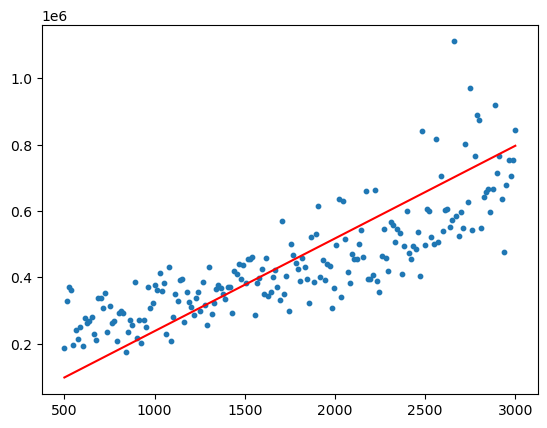

In [98]:
sqft_range = np.linspace(
    start=500,
    stop=3000,
    num=200
)

typical_sqft_df = pd.DataFrame(data=sqft_range, columns=['sqft_living'])

lr_pred = model.predict(typical_sqft_df)
k_pred = k_model.predict(typical_sqft_df)

plt.plot(typical_sqft_df, lr_pred, color='red')
plt.scatter(typical_sqft_df, k_pred, s=10)

## 11. Finally, let's see what happens when we add another variable. Create a new linear regression model which uses both the square footage of living space and whether or not it is waterfront. When you do this, make sure that you're using the same train and test split by using the same random_state as above. By how much does this improve the model's fit?

In [102]:
X = kc_house_df[['sqft_living', 'waterfront']]

In [103]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=random_state
)

In [104]:
model = LinearRegression().fit(X_train, y_train)

In [105]:
model.score(X_test, y_test)

# 0.48388319278201475

0.5312973700064663

** If you've reached this point, let your instructors know so that they can check in with you. **

# Stretch Goals

## 1. One way to add complexity to the model is through using interaction terms. These allow for the relationship between sqft_living and price to differ for waterfront and non-waterfront properties. Create a column containing the product of sqft_living and waterfront. Add this to your model. Does it improve the performance? Interpret the meaning of the coefficients for the model containing the interaction.

## 2. Take a look at the distribution of home prices. You'll find that it's highly skewed. When the target is skewed, it can be beneficial to transform the target so that it is closer to normally-distributed in order to reduce the effect of extreme values. **Important Note:** When comparing metrics for a transformed target and an untransformed target, it is important that you apply an inverse transformation to the predictions from the transformed model. This can be done using a [TransformedTargetRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.compose.TransformedTargetRegressor.html). Try using a log transformation on the target. Does this improve the metrics for the model? 